

### How RNNs Work

1. **Input Sequence**: The RNN processes an input sequence one element at a time. For example, in natural language processing, this could be one word at a time.

2. **Hidden State Update**: At each time step \( t \), the RNN takes the current input \( x_t \) and the previous hidden state \( h_{t-1} \) to compute the new hidden state \( h_t \). This is typically done using a function like:
   \[
   h_t = \tanh(W_{hx} x_t + W_{hh} h_{t-1} + b_h)
   \]
   where \( W_{hx} \) and \( W_{hh} \) are weight matrices, and \( b_h \) is a bias vector.

3. **Output Generation**: The RNN can produce an output at each time step, which is often computed using the hidden state:
   \[
   y_t = W_{hy} h_t + b_y
   \]
   where \( W_{hy} \) is a weight matrix, and \( b_y \) is a bias vector.

4. **Backpropagation Through Time (BPTT)**: Training an RNN involves adjusting the weights to minimize the error between the predicted and actual outputs. This is done using a variant of backpropagation called Backpropagation Through Time, which takes into account the dependencies between time steps.

### Example in Python (using PyTorch)

Here's a simple example of an RNN implemented in Python using the PyTorch library:



Epoch 0, Loss: 9.393775391578675
Epoch 100, Loss: 9.177088012695313
Epoch 200, Loss: 9.172731637954712
Epoch 300, Loss: 9.170052289962769
Epoch 400, Loss: 9.167442970275879
Epoch 500, Loss: 9.168126201629638
Epoch 600, Loss: 9.167316031455993
Epoch 700, Loss: 9.16680049419403
Epoch 800, Loss: 9.166696491241455
Epoch 900, Loss: 9.166189379692078


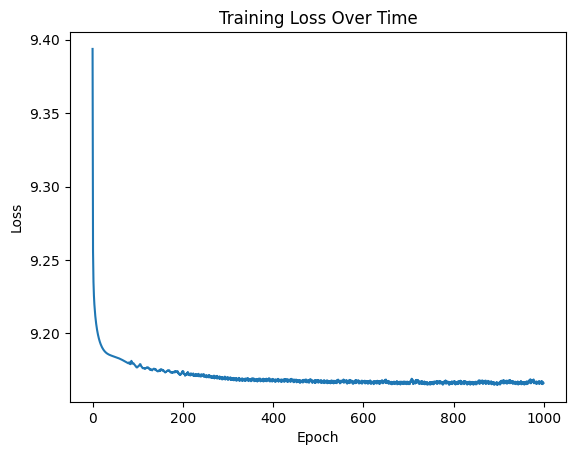

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

# Hyperparameters
input_size = 57
hidden_size = 128
output_size = 18
learning_rate = 0.001
epochs = 1000

# Initialize the RNN
rnn = SimpleRNN(input_size, hidden_size, output_size)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn.parameters(), lr=learning_rate)

# Generate dummy data
data = [torch.randn(1, input_size) for _ in range(100)]
targets = [torch.randn(1, output_size) for _ in range(100)]

# Training loop
losses = []
for epoch in range(epochs):
    total_loss = 0
    for i in range(len(data)):
        input = data[i]
        target = targets[i]
        hidden = rnn.initHidden()

        optimizer.zero_grad()
        output, hidden = rnn(input, hidden)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(data)
    losses.append(avg_loss)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss}')

# Plot the training loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

In [13]:
import torch

# Assuming the previous code has been executed and the RNN model is trained

# Save the model
torch.save(rnn.state_dict(), 'rnn_model.pth')

# Load the model
loaded_rnn = SimpleRNN(input_size, hidden_size, output_size)
loaded_rnn.load_state_dict(torch.load('rnn_model.pth'))
loaded_rnn.eval()  # Set the model to evaluation mode

# Function to make predictions
def predict(rnn, input_sequence):
    hidden = rnn.initHidden()
    for i in range(len(input_sequence)):
        input = input_sequence[i].view(1, -1)  # Reshape input to match the expected input size
        output, hidden = rnn(input, hidden)
    return output

# Example usage
# Create a new dummy input sequence (e.g., 9 time steps, each with 57 features)
new_sequence = [torch.randn(1, input_size) for _ in range(9)]

# Make a prediction for the 10th day using the loaded model
predicted_output = predict(loaded_rnn, new_sequence)
print(f'Predicted output: {predicted_output}')

# # Assuming the previous code has been executed and the RNN model is trained

# # Function to make predictions
# def predict(rnn, input_sequence):
#     hidden = rnn.initHidden()
#     for i in range(len(input_sequence)):
#         input = input_sequence[i].view(1, -1)  # Reshape input to match the expected input size
#         output, hidden = rnn(input, hidden)
#     return output

# # Example usage
# # Create a new dummy input sequence (e.g., 9 time steps, each with 57 features)
# new_sequence = [torch.randn(1, input_size) for _ in range(9)]

# # Make a prediction for the 10th day
# predicted_output = predict(rnn, new_sequence)
# print(f'Predicted output: {predicted_output}')

Predicted output: tensor([[-2.8645, -2.6878, -3.3940, -2.1826, -2.8313, -2.8673, -3.3344, -3.0849,
         -2.9341, -3.3010, -2.8249, -3.1537, -2.8216, -3.3107, -2.6821, -2.6837,
         -3.2176, -2.7082]], grad_fn=<LogSoftmaxBackward0>)


## lesgo with stock market example

To design an RNN that predicts the stock market price for the 10th day using the previous 9 days' market prices, we'll follow these steps:

1. **Data Preparation**: Prepare the dataset with sequences of 9 days' prices as input and the 10th day's price as the target.
2. **RNN Design**: Implement the RNN architecture.
3. **Training Loop**: Train the RNN on the dataset.
4. **Prediction**: Use the trained model to predict the 10th day's price.

### Pseudocode

1. **Initialize Parameters**: Define the weight matrices and bias vectors.
2. **Forward Pass**:
   - Compute the hidden state for each time step.
   - Compute the output for the final time step.
3. **Loss Calculation**: Compute the mean squared error loss.
4. **Backward Pass**: Compute gradients and update parameters using gradient descent.
5. **Training Loop**: Iterate over the dataset to train the model.
6. **Prediction**: Use the trained model to predict the 10th day's price.

### Code



In [3]:
import numpy as np

class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        self.Wxh = np.random.randn(hidden_size, input_size) * 0.01  # input to hidden
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01  # hidden to hidden
        self.Why = np.random.randn(output_size, hidden_size) * 0.01  # hidden to output
        self.bh = np.zeros((hidden_size, 1))  # hidden bias
        self.by = np.zeros((output_size, 1))  # output bias

    def forward(self, inputs):
        h_prev = np.zeros((self.hidden_size, 1))
        for x in inputs:
            x = x.reshape(-1, 1)
            h_prev = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h_prev) + self.bh)
        y = np.dot(self.Why, h_prev) + self.by
        return y, h_prev

    def loss(self, predicted, actual):
        return np.mean((predicted - actual) ** 2)

    def backward(self, inputs, h_prev, predicted, actual, learning_rate=0.001):
        dWhy = np.dot((predicted - actual), h_prev.T)
        dby = predicted - actual
        dWhh = np.zeros_like(self.Whh)
        dWxh = np.zeros_like(self.Wxh)
        dbh = np.zeros_like(self.bh)
        dh_next = np.dot(self.Why.T, (predicted - actual))

        for t in reversed(range(len(inputs))):
            x = inputs[t].reshape(-1, 1)
            dh = (1 - h_prev ** 2) * dh_next
            dbh += dh
            dWxh += np.dot(dh, x.T)
            dWhh += np.dot(dh, h_prev.T)
            dh_next = np.dot(self.Whh.T, dh)

        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -1, 1, out=dparam)

        self.Wxh -= learning_rate * dWxh
        self.Whh -= learning_rate * dWhh
        self.Why -= learning_rate * dWhy
        self.bh -= learning_rate * dbh
        self.by -= learning_rate * dby

    def train(self, data, targets, epochs=1000, learning_rate=0.001):
        for epoch in range(epochs):
            total_loss = 0
            for i in range(len(data)):
                inputs = data[i]
                target = targets[i].reshape(-1, 1)
                predicted, h_prev = self.forward(inputs)
                total_loss += self.loss(predicted, target)
                self.backward(inputs, h_prev, predicted, target, learning_rate)
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {total_loss / len(data)}')

# Example usage
input_size = 1
hidden_size = 10
output_size = 1
rnn = SimpleRNN(input_size, hidden_size, output_size)

# Create dummy data (e.g., 100 sequences, each with 9 days of prices)
data = [np.random.randn(9, input_size) for _ in range(100)]
#print the data to see the random values 
print(data)
targets = [np.random.randn(output_size) for _ in range(100)]

rnn.train(data, targets, epochs=1000, learning_rate=0.001)

# Predict the 10th day's price for a new sequence
new_sequence = np.random.randn(9, input_size)
predicted_price, _ = rnn.forward(new_sequence)
print(f'Predicted 10th day price: {predicted_price.ravel()[0]}')

[array([[-2.11301053],
       [-1.21312882],
       [ 0.32186176],
       [-0.32745034],
       [ 1.24594471],
       [ 1.24498102],
       [ 0.02838197],
       [-0.76694989],
       [-0.55355475]]), array([[ 1.33319567],
       [ 1.346491  ],
       [-1.11042007],
       [-0.37205741],
       [-1.68338555],
       [-1.03358395],
       [-1.51848011],
       [-0.19969879],
       [-0.70876812]]), array([[ 1.54968759],
       [ 0.83391749],
       [-0.91730012],
       [-0.87355327],
       [-0.32979616],
       [ 1.39643634],
       [-0.6691867 ],
       [ 1.02455162],
       [ 0.54195292]]), array([[-1.12241737],
       [-0.77268747],
       [-0.69829184],
       [ 0.78683899],
       [-0.12578807],
       [-0.4331735 ],
       [-0.23295295],
       [-2.34344447],
       [-0.87976276]]), array([[ 0.0952333 ],
       [ 0.03316308],
       [-1.0745779 ],
       [-0.58977344],
       [ 0.51180001],
       [ 0.69206332],
       [ 1.26262713],
       [ 1.30715259],
       [-2.37233905]]),